In [1]:
import numpy as np
from scipy.stats import unitary_group
import pennylane as qml
import time
from tqdm.auto import tqdm
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'                                                                  
plt.rcParams['font.size'] = 18                                                                         
plt.rcParams['text.usetex'] = True 

In [2]:
import rotoptsynth as ros
ros.disable_validation()


def benchmark(ns: list[int], num_runs: dict[int], seed: int) -> tuple[dict[int, float]]:    
    cpu_times = {}
    wall_times = {}
    
    
    very_first_exec_start_cpu = time.process_time()
    very_first_exec_start_wall = time.time()
    ops = ros.rot_opt_qsd(unitary_group.rvs(2**min(ns), random_state=seed), wires=range(min(ns)), zeroed_wires=None)
    cpu_times["very_first_exec"] = time.process_time() - very_first_exec_start_cpu
    wall_times["very_first_exec"] = time.time() - very_first_exec_start_wall
    for n in tqdm(ns):
        targets = unitary_group.rvs(2**n, size=num_runs[n], random_state=seed)
        cpu_times[n] = {}
        wall_times[n] = {}
        first_exec_start_cpu = time.process_time()
        first_exec_start_wall = time.time()
        ops = ros.rot_opt_qsd(targets[0], wires=range(n), zeroed_wires=None)
        cpu_times[n]["first_exec"] = time.process_time() - first_exec_start_cpu
        wall_times[n]["first_exec"] = time.time() - first_exec_start_wall

        all_execs_start_cpu = time.process_time()
        all_execs_start_wall = time.time()
        for target in tqdm(targets):
            ops = ros.rot_opt_qsd(target, wires=range(n), zeroed_wires=None)
        cpu_times[n]["all_execs"] = time.process_time() - all_execs_start_cpu
        wall_times[n]["all_execs"] = time.time() - all_execs_start_wall

        cpu_times[n]["per_exec"] = cpu_times[n]["all_execs"] / num_runs[n]
        wall_times[n]["per_exec"] = wall_times[n]["all_execs"] / num_runs[n]

    return cpu_times, wall_times
        

In [3]:
ns = range(3, 13)
num_runs = {n: int(1000/(n-2)**2) for n in ns}
# num_runs = {n: 2 for n in ns}
print(num_runs)
# %prun -s cumtime cpu_times, wall_times = benchmark(ns, num_runs, 8251204)
cpu_times, wall_times = benchmark(ns, num_runs, 8251204)

{3: 1000, 4: 250, 5: 111, 6: 62, 7: 40, 8: 27, 9: 20, 10: 15, 11: 12, 12: 10}


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

/Users/david.wierichs/repos/rotoptsynth/rotoptsynth/flag_decomp.py:116: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(complex128, 2, 'A', False, aligned=True), Array(complex128, 2, 'C', True, aligned=True))
  u_mod = u @ _cnot  # Optimize cnot multiplication away


  0%|          | 0/250 [00:00<?, ?it/s]

...

  0%|          | 0/27 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

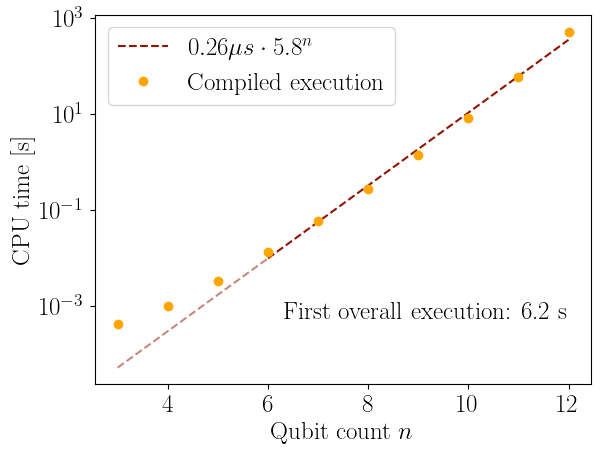

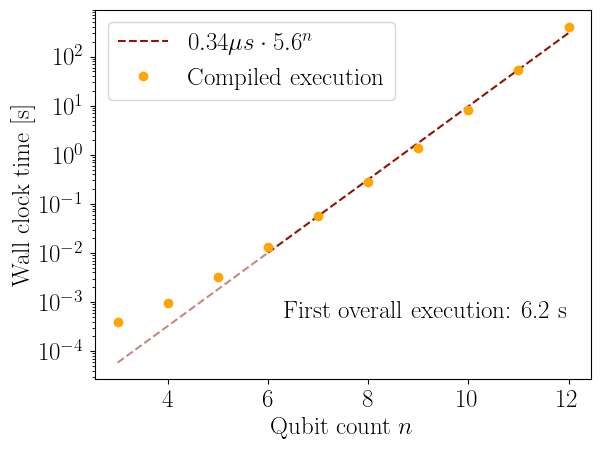

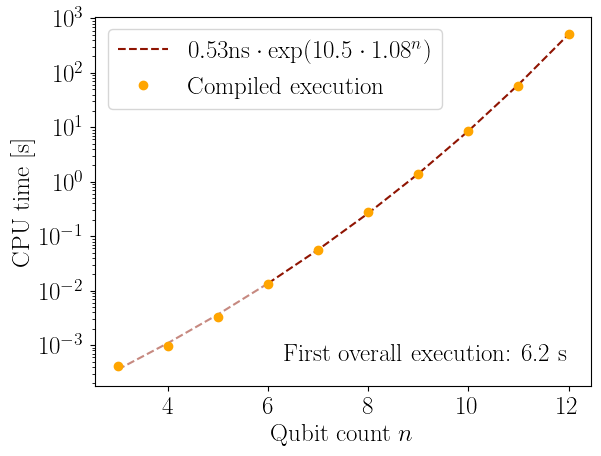

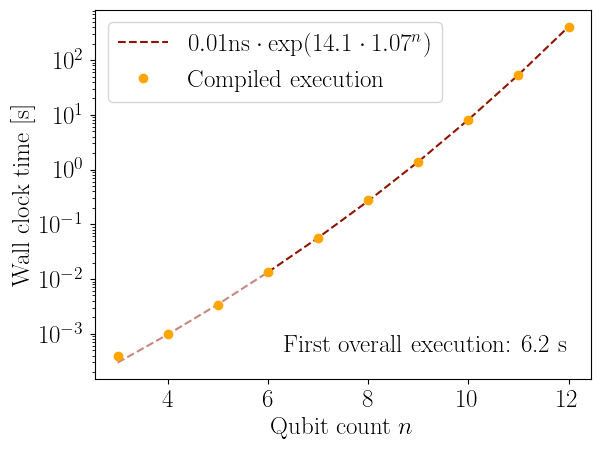

In [30]:

for fit_type in ["linear", "exp"]:
    
    if fit_type == "exp":
        def fit_fun(x, a, b, c):
            return a * np.exp(b * x) + c
        p0 = (1e-5, 2, 1)
        
    elif fit_type == "linear":
        def fit_fun(x, a, b):
            return a + b * x
        p0 = (1e-5, 2)
        
    else:
        raise NotImplementedError
        
    time_labels = ["CPU time", "Wall clock time"]
    for times, time_label in zip([cpu_times, wall_times], time_labels):
        fig, axs = plt.subplots(1, 1)
        ax = axs
        
        fit_cutoff = 3
        times_per_exec = [times[n]["per_exec"] for n in ns]
        popt, pcov = curve_fit(fit_fun, ns[fit_cutoff:], np.log(times_per_exec[fit_cutoff:]), p0=p0)
        fit = np.exp(fit_fun(np.array(ns), *popt))
        if fit_type == "linear":
            a, b = popt
            fit_label = f"${np.exp(a)*1e6:.2f}\\mu s\\cdot{np.exp(b):.1f}^n$" # Linear for log data
        elif fit_type == "exp":
            a, b, c = popt
            fit_label = f"${np.exp(c)*1e9:.2f}\\mathrm{{ns}}\\cdot \\exp({a:.1f} \\cdot {np.exp(b):.2f}^n)$" # Exp for log data (!)
            
        ax.plot(ns[fit_cutoff:], fit[fit_cutoff:], ls="--", color="xkcd:brick red", label=fit_label)
        ax.plot(ns[:fit_cutoff+1], fit[:fit_cutoff+1], ls="--", color="xkcd:brick red", alpha=0.5)
        ax.plot(ns, times_per_exec, marker="o", ls="", color="orange", label="Compiled execution")
        ax.text(max(ns), times[min(ns)]["per_exec"], s=f"First overall execution: {times['very_first_exec']:.1f} s", ha="right", va="bottom")
        ax.set_xlabel("Qubit count $n$")
        ax.set_ylabel(time_label + " $[\\mathrm{s}]$")
        ax.set_yscale("log")
        ax.legend()
        char = time_label.split(" ")[0].lower()
        plt.savefig(f"/Users/david.wierichs/Desktop/ros_compile_time_{char}_3_to_12_{fit_type}.pdf", dpi=400, bbox_inches="tight")
    # plt.close()

In [29]:
cpu_times

{'very_first_exec': 6.1804060000000005,
 3: {'first_exec': 0.000890999999999309,
  'all_execs': 0.41591800000000045,
  'per_exec': 0.00041591800000000047},
 4: {'first_exec': 0.514988999999999,
  'all_execs': 0.24580900000000128,
  'per_exec': 0.0009832360000000052},
 5: {'first_exec': 0.0035520000000008878,
  'all_execs': 0.36852399999999896,
  'per_exec': 0.0033200360360360268},
 6: {'first_exec': 0.013776999999999262,
  'all_execs': 0.8223000000000003,
  'per_exec': 0.013262903225806456},
 7: {'first_exec': 0.056708999999999676,
  'all_execs': 2.2808829999999993,
  'per_exec': 0.057022074999999985},
 8: {'first_exec': 0.27937999999999974,
  'all_execs': 7.408506999999998,
  'per_exec': 0.2743891481481481},
 9: {'first_exec': 1.4127990000000032,
  'all_execs': 28.174078,
  'per_exec': 1.4087039000000001},
 10: {'first_exec': 8.299833999999997,
  'all_execs': 126.25967299999999,
  'per_exec': 8.417311533333333},
 11: {'first_exec': 57.793233000000015,
  'all_execs': 698.128198,
  'per